# Baseline Modeling

In [1]:
# ==============
# 0. 라이브러리
# ==============
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

In [2]:
# ===============
# 1. 데이터 로드
# ===============
df = pd.read_csv("train_baseline.csv")

TARGET = "fraud"

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()

print("데이터 크기:", df.shape)
print("타깃 비율:")
print(y.value_counts(normalize=True))

데이터 크기: (18000, 25)
타깃 비율:
fraud
0    0.841778
1    0.158222
Name: proportion, dtype: float64


In [3]:
# ==================
# 2. 입력/타깃 분리
# ==================
TARGET = "fraud"

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()

In [4]:
# ================================================
# 3. 범주형 컬럼 처리
#    LightGBM이 category dtype을 직접 처리하게 함
# ================================================
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

for col in cat_cols:
    X[col] = X[col].astype("category")

print("\n범주형 컬럼:")
print(cat_cols)


범주형 컬럼:
['gender', 'living_status', 'accident_site', 'channel', 'vehicle_category', 'vehicle_color', 'claim_day_of_week']


In [5]:
# ========================
# 4. OOF / 결과 저장 변수
# ========================
oof_pred = np.zeros(len(X))
oof_pred_label = np.zeros(len(X))

fold_scores = []
feature_importance_list = []

models = []

In [6]:
# =========================================================
# 5. CV 설정
# =========================================================
N_SPLITS = 5
RANDOM_STATE = 2542

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [7]:
# ==================
# 6. Fold 반복 학습
# ==================

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n{'='*20} Fold {fold} {'='*20}")

    X_train, X_valid = X.iloc[train_idx].copy(), X.iloc[valid_idx].copy()
    y_train, y_valid = y.iloc[train_idx].copy(), y.iloc[valid_idx].copy()

    # 클래스 불균형 반영
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos

    model = lgb.LGBMClassifier(
        objective="binary",
        boosting_type="gbdt",
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=0.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="auc",
        categorical_feature=cat_cols,
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(period=100)
        ]
    )

    # validation prediction
    valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    valid_pred_label = (valid_pred_proba >= 0.5).astype(int)

    # OOF 저장
    oof_pred[valid_idx] = valid_pred_proba
    oof_pred_label[valid_idx] = valid_pred_label

    # fold metric
    fold_auc = roc_auc_score(y_valid, valid_pred_proba)
    fold_pr_auc = average_precision_score(y_valid, valid_pred_proba)
    fold_f1 = f1_score(y_valid, valid_pred_label)

    print(f"Fold {fold} ROC-AUC : {fold_auc:.4f}")
    print(f"Fold {fold} PR-AUC  : {fold_pr_auc:.4f}")
    print(f"Fold {fold} F1      : {fold_f1:.4f}")

    fold_scores.append({
        "fold": fold,
        "roc_auc": fold_auc,
        "pr_auc": fold_pr_auc,
        "f1": fold_f1
    })

    # feature importance 저장
    fold_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": model.feature_importances_,
        "fold": fold
    })
    feature_importance_list.append(fold_importance)

    models.append(model)


==================== Fold 1 ====================
[LightGBM] [Info] Number of positive: 2279, number of negative: 12121
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001696 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2160
[LightGBM] [Info] Number of data points in the train set: 14400, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.158264 -> initscore=-1.671203
[LightGBM] [Info] Start training from score -1.671203
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.685944	valid_0's binary_logloss: 0.583976
Early stopping, best iteration is:
[2]	valid_0's auc: 0.666421	valid_0's binary_logloss: 0.432191
Fold 1 ROC-AUC : 0.6664
Fold 1 PR-AUC  : 0.2557
Fold 1 F1      : 0.0000

==================== Fold 2 ====================
[LightGBM] [Info] Number of positive: 2279, nu

In [8]:
# ==================
# 7. Fold 결과 요약
# ==================
score_df = pd.DataFrame(fold_scores)

print("\n========== Fold Scores ==========")
print(score_df)

print("\n========== CV Mean Scores ==========")
print(f"Mean ROC-AUC : {score_df['roc_auc'].mean():.4f}")
print(f"Std  ROC-AUC : {score_df['roc_auc'].std():.4f}")
print(f"Mean PR-AUC  : {score_df['pr_auc'].mean():.4f}")
print(f"Mean F1      : {score_df['f1'].mean():.4f}")


========== Fold Scores ==========
   fold   roc_auc    pr_auc   f1
0     1  0.666421  0.255662  0.0
1     2  0.692088  0.264389  0.0
2     3  0.653261  0.242393  0.0
3     4  0.684485  0.276998  0.0
4     5  0.671801  0.264396  0.0

========== CV Mean Scores ==========
Mean ROC-AUC : 0.6736
Std  ROC-AUC : 0.0152
Mean PR-AUC  : 0.2608
Mean F1      : 0.0000


In [9]:
# ===========================
# 8. 전체 OOF 기준 성능 평가
# ===========================
oof_auc = roc_auc_score(y, oof_pred)
oof_pr_auc = average_precision_score(y, oof_pred)
oof_f1 = f1_score(y, oof_pred_label)

print("\n========== OOF Overall Performance ==========")
print(f"OOF ROC-AUC : {oof_auc:.4f}")
print(f"OOF PR-AUC  : {oof_pr_auc:.4f}")
print(f"OOF F1      : {oof_f1:.4f}")

print("\n========== OOF Confusion Matrix ==========")
print(confusion_matrix(y, oof_pred_label))

print("\n========== OOF Classification Report ==========")
print(classification_report(y, oof_pred_label, digits=4))


========== OOF Overall Performance ==========
OOF ROC-AUC : 0.6570
OOF PR-AUC  : 0.2541
OOF F1      : 0.0000

========== OOF Confusion Matrix ==========
[[15152     0]
 [ 2848     0]]

========== OOF Classification Report ==========
              precision    recall  f1-score   support

           0     0.8418    1.0000    0.9141     15152
           1     0.0000    0.0000    0.0000      2848

    accuracy                         0.8418     18000
   macro avg     0.4209    0.5000    0.4570     18000
weighted avg     0.7086    0.8418    0.7695     18000



C:\Users\tjdgu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tjdgu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tjdgu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


- OOF ROC-AUC score가 0.67 정도로 나오는 걸로 볼 때, 모델은 fraud 확률을 구분하고 있음.
- 하지만 threshold = 0.5에서는 fraud를 제대로 예측하지 못하고 있음.
- 따라서 threshold 조정 필요.

In [10]:
# ============================
# 9. 평균 Feature Importance
# ============================
importance_df = pd.concat(feature_importance_list, axis=0)

mean_importance = (
    importance_df
    .groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print("\n========== Mean Feature Importance ==========")
print(mean_importance.head(20))


========== Mean Feature Importance ==========
                    feature  importance
0              safty_rating         8.6
1             age_of_driver         8.4
2        address_change_ind         5.8
3        high_education_ind         5.0
4       witness_present_ind         4.4
5            marital_status         3.8
6             accident_site         3.0
7             annual_income         3.0
8                 liab_prct         2.6
9             vehicle_price         2.6
10           vehicle_weight         2.2
11            living_status         1.4
12         claim_est_payout         1.0
13                   gender         0.8
14      payout_income_ratio         0.6
15           age_of_vehicle         0.4
16         vehicle_category         0.2
17  policy_report_filed_ind         0.2
18            vehicle_color         0.0
19       past_num_of_claims         0.0


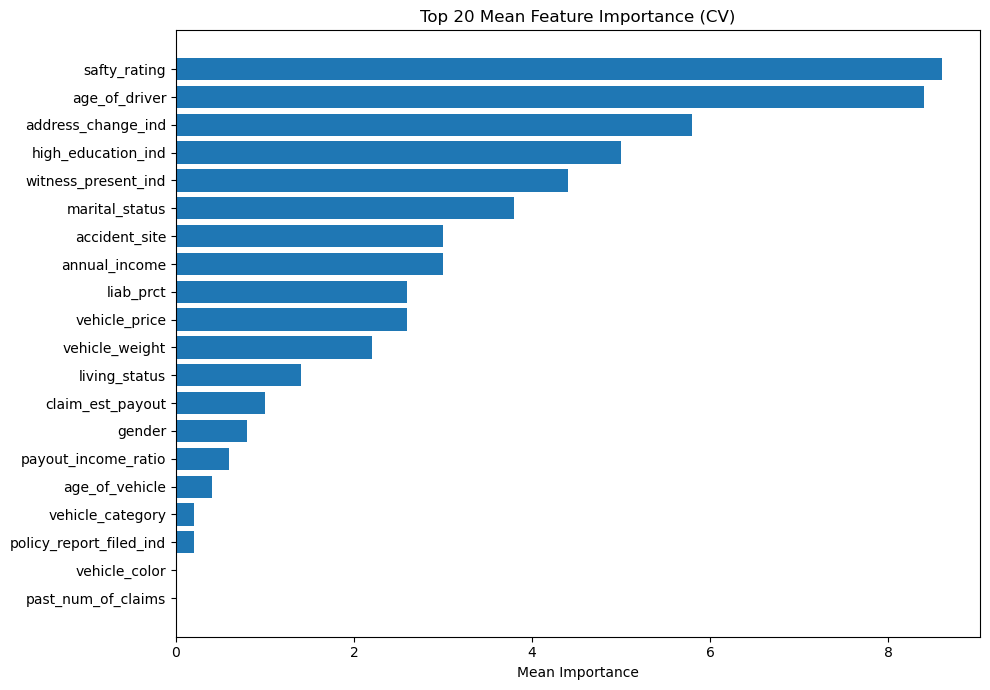

In [11]:
# =============================
# 10. Feature Importance 시각화
# =============================
top_k = 20

plt.figure(figsize=(10, 7))
plt.barh(
    mean_importance["feature"].head(top_k)[::-1],
    mean_importance["importance"].head(top_k)[::-1]
)
plt.title("Top 20 Mean Feature Importance (CV)")
plt.xlabel("Mean Importance")
plt.tight_layout()
plt.show()

In [12]:
# ======================
# 11. Threshold Tuning
# ======================
threshold_list = np.arange(0.05, 0.51, 0.05)

result_list = []

print("========== Threshold Tuning ==========")

for th in threshold_list:
    
    pred_label = (oof_pred >= th).astype(int)
    
    f1 = f1_score(y, pred_label)
    precision = precision_score(y, pred_label, zero_division=0)
    recall = recall_score(y, pred_label)
    
    tn, fp, fn, tp = confusion_matrix(y, pred_label).ravel()
    
    result_list.append({
        "threshold": th,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn
    })
    
    print(f"\nThreshold = {th:.2f}")
    print(f"F1        : {f1:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"TP={tp} FP={fp} FN={fn} TN={tn}")

result_df = pd.DataFrame(result_list)

========== Threshold Tuning ==========

Threshold = 0.05
F1        : 0.2732
Precision : 0.1582
Recall    : 1.0000
TP=2848 FP=15152 FN=0 TN=0

Threshold = 0.10
F1        : 0.2732
Precision : 0.1582
Recall    : 1.0000
TP=2848 FP=15152 FN=0 TN=0

Threshold = 0.15
F1        : 0.2733
Precision : 0.1583
Recall    : 0.9989
TP=2845 FP=15129 FN=3 TN=23

Threshold = 0.20
F1        : 0.3084
Precision : 0.2763
Recall    : 0.3490
TP=994 FP=2604 FN=1854 TN=12548

Threshold = 0.25
F1        : 0.0000
Precision : 0.0000
Recall    : 0.0000
TP=0 FP=0 FN=2848 TN=15152

Threshold = 0.30
F1        : 0.0000
Precision : 0.0000
Recall    : 0.0000
TP=0 FP=0 FN=2848 TN=15152

Threshold = 0.35
F1        : 0.0000
Precision : 0.0000
Recall    : 0.0000
TP=0 FP=0 FN=2848 TN=15152

Threshold = 0.40
F1        : 0.0000
Precision : 0.0000
Recall    : 0.0000
TP=0 FP=0 FN=2848 TN=15152

Threshold = 0.45
F1        : 0.0000
Precision : 0.0000
Recall    : 0.0000
TP=0 FP=0 FN=2848 TN=15152

Threshold = 0.50
F1        : 0.0000


In [13]:
best_row = result_df.loc[result_df["f1"].idxmax()]

print("\n========== Best Threshold ==========")
print(best_row)


========== Best Threshold ==========
threshold        0.200000
f1               0.308408
precision        0.276265
recall           0.349017
tp             994.000000
fp            2604.000000
fn            1854.000000
tn           12548.000000
Name: 3, dtype: float64


In [14]:
# =====================
# 12. Recall@TopK 확인
# =====================
def recall_at_k(y_true, pred_prob, k_ratio=0.1):
    
    k = int(len(pred_prob) * k_ratio)
    
    top_idx = np.argsort(pred_prob)[::-1][:k]
    
    recall = y_true.iloc[top_idx].sum() / y_true.sum()
    
    return recall

In [15]:
k_list = [0.01, 0.03, 0.05, 0.10, 0.20, 0.30]

for k in k_list:
    recall_k = recall_at_k(y, oof_pred, k_ratio=k)
    print(f"Recall@Top{int(k*100)}%: {recall_k:.4f}")

Recall@Top1%: 0.0225
Recall@Top3%: 0.0681
Recall@Top5%: 0.1053
Recall@Top10%: 0.1977
Recall@Top20%: 0.3490
Recall@Top30%: 0.4638


- 모델이 fraud probability를 완전히 랜덤으로 산출하지는 않음.
- 하지만 ranking sharpness가 부족한 상태
- 따라서 feature engineering 필요